# LOGISTIC REGRESSION MODELS FOR CREDIT EVALUATION

## IMPORTS AND DATA PREPARATION

### IMPORTS

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

### PATHS

In [2]:
PROJECT_ROOT = Path("/Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval")

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH    = DATA_DIR / "train.csv"
VALIDATE_PATH = DATA_DIR / "validate.csv"
TEST_PATH     = DATA_DIR / "test.csv"

LOGREG_OUTPUT_DIR = PROJECT_ROOT / "output" / "logreg"
LOGREG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Unconstrained outputs
UNC_BASELINE_CSV        = LOGREG_OUTPUT_DIR / "logreg_unconstrained_baseline_validation_results.csv"
UNC_TUNING_CSV          = LOGREG_OUTPUT_DIR / "logreg_unconstrained_tuning_results_validation.csv"
UNC_VALIDATION_CMP_CSV  = LOGREG_OUTPUT_DIR / "logreg_unconstrained_validation_comparison.csv"
UNC_SELECTED_CSV        = LOGREG_OUTPUT_DIR / "logreg_unconstrained_selected_model_validation.csv"

# Constrained outputs
CON_FIXED_CSV           = LOGREG_OUTPUT_DIR / "logreg_constrained_fixed_selected_model_validation.csv"
CON_RETUNED_TUNING_CSV  = LOGREG_OUTPUT_DIR / "logreg_constrained_retuned_tuning_results_validation.csv"
CON_RETUNED_SELECTED_CSV= LOGREG_OUTPUT_DIR / "logreg_constrained_retuned_selected_model_validation.csv"
CON_VALIDATION_CMP_CSV  = LOGREG_OUTPUT_DIR / "logreg_constrained_validation_comparison.csv"

# Final comparison
FINAL_COMPARISON_CSV    = LOGREG_OUTPUT_DIR / "logreg_final_comparison.csv"

RANDOM_STATE = 42
SOLVER_MAP   = {"l1": "saga", "l2": "lbfgs"}

### DATA VALIDATION

In [3]:
train_df    = pd.read_csv(TRAIN_PATH,    low_memory=False)
validate_df = pd.read_csv(VALIDATE_PATH, low_memory=False)
test_df     = pd.read_csv(TEST_PATH,     low_memory=False)

print("Shapes:")
print(f"  train:    {train_df.shape}")
print(f"  validate: {validate_df.shape}")
print(f"  test:     {test_df.shape}")
print("\nColumn match:")
print("  train / validate:", list(train_df.columns) == list(validate_df.columns))
print("  train / test:    ", list(train_df.columns) == list(test_df.columns))

Shapes:
  train:    (215137, 33)
  validate: (46101, 33)
  test:     (46101, 33)

Column match:
  train / validate: True
  train / test:     True


In [4]:
TARGET_COLUMN = "TARGET"
ID_COLUMN     = "SK_ID_CURR"

print("Default rate by split:")
print("  Train:   ", train_df[TARGET_COLUMN].mean())
print("  Validate:", validate_df[TARGET_COLUMN].mean())
print("  Test:    ", test_df[TARGET_COLUMN].mean())

dtype_to_columns = (
    train_df.dtypes
    .astype(str)
    .groupby(train_df.dtypes.astype(str))
    .apply(lambda s: sorted(s.index.tolist()))
)
print("\nFeatures by dtype:")
for dtype_name, columns in dtype_to_columns.items():
    print(f"  {dtype_name}: {columns}")

Default rate by split:
  Train:    0.08072995347150885
  Validate: 0.08073577579662046
  Test:     0.08071408429318236

Features by dtype:
  float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
  int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'SK_ID_CURR', 'TARGET']
  str: ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']



NOTE: MISSING VALUES with Logistic Regression**  
Unlike XGBoost, logistic regression cannot handle NaN natively.  
Numeric columns are imputed with training-set median (fit on train only, applied to val/test).  
Categorical columns already have `MISSING` placeholder from preprocessing.

### PREP DATA FOR MODEL TRAINING

##### Separate labels

In [5]:
y_train = train_df[TARGET_COLUMN].astype(int).copy()
y_val   = validate_df[TARGET_COLUMN].astype(int).copy()
y_test  = test_df[TARGET_COLUMN].astype(int).copy()

X_train = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_val   = validate_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_test  = test_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()

print(f"X_train | shape: {X_train.shape}  | type: {type(X_train)}")
print(f"X_val   | shape: {X_val.shape}    | type: {type(X_val)}")
print(f"X_test  | shape: {X_test.shape}   | type: {type(X_test)}")
print()
print(f"y_train | shape: {y_train.shape}  | type: {type(y_train)}")
print(f"y_val   | shape: {y_val.shape}    | type: {type(y_val)}")
print(f"y_test  | shape: {y_test.shape}   | type: {type(y_test)}")

X_train | shape: (215137, 31)  | type: <class 'pandas.DataFrame'>
X_val   | shape: (46101, 31)    | type: <class 'pandas.DataFrame'>
X_test  | shape: (46101, 31)   | type: <class 'pandas.DataFrame'>

y_train | shape: (215137,)  | type: <class 'pandas.Series'>
y_val   | shape: (46101,)    | type: <class 'pandas.Series'>
y_test  | shape: (46101,)   | type: <class 'pandas.Series'>


##### Identify column types

In [6]:
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_columns     = [col for col in X_train.columns if col not in categorical_columns]

print(f"# numeric columns:     {len(numeric_columns)}")
print(f"# categorical columns: {len(categorical_columns)}")
print("\nNumeric:",     numeric_columns)
print("\nCategorical:", categorical_columns)

# numeric columns:     23
# categorical columns: 8

Numeric: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING']

Categorical: ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


## EVALUATION METRICS

(Same for constrained and unconstrained models)

### Kolmogorov-Smirnov (KS) Stat

Very common in credit scoring. Measures the point where the model does the best job of
separating defaulters from good borrowers.

In [7]:
def compute_ks(y_true, y_score):
    """
    Returns maximum absolute separation between those two curves as float.
    """
    df_ks = pd.DataFrame({
        "y_true":  pd.Series(y_true).reset_index(drop=True),
        "y_score": pd.Series(y_score).reset_index(drop=True),
    }).sort_values("y_score", ascending=False).reset_index(drop=True)

    total_pos = (df_ks["y_true"] == 1).sum()
    total_neg = (df_ks["y_true"] == 0).sum()

    if total_pos == 0 or total_neg == 0:
        return np.nan

    df_ks["cum_pos"] = (df_ks["y_true"] == 1).cumsum() / total_pos
    df_ks["cum_neg"] = (df_ks["y_true"] == 0).cumsum() / total_neg

    return float(np.max(np.abs(df_ks["cum_pos"] - df_ks["cum_neg"])))

### Eval Helpers

##### Compute metrics

Helper func to evaluate fitted model with metrics:
- **PR-AUC** *(primary)* — tradeoff between precision and recall (esp. important given class imbalance)
- **ROC-AUC** — how well model ranks true defaulters over non-defaulters across classification thresholds
- **Brier Score** — how close predicted default probabilities are to actual outcomes
- **KS Statistic** — maximum separation between cumulative distributions of defaulters and non-defaulters when ranked by predicted risk

*PR-AUC is the primary metric by which candidate models are selected during hyperparameter tuning*
*because of the large class imbalance in defaulters vs non-defaulters*

In [8]:
def evaluate_binary_model(model, X, y, split_name, model_name):
    """
    Evaluates trained model, returns dict with metrics and metadata.
    """
    y_proba = model.predict_proba(X)[:, 1]

    return {
        "model_name":  model_name,
        "split":       split_name,
        "pr_auc":      average_precision_score(y, y_proba),
        "roc_auc":     roc_auc_score(y, y_proba),
        "brier_score": brier_score_loss(y, y_proba),
        "ks_stat":     compute_ks(y, y_proba),
    }

##### Plots

In [9]:
def plot_roc_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_value   = roc_auc_score(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_value:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_pr_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc_value = average_precision_score(y_true, y_proba)
        plt.plot(recall, precision, label=f"{label} (PR-AUC = {pr_auc_value:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_metric_comparison(results_df, split_name, metric_name, title):
    plot_df = results_df[results_df["split"] == split_name].copy()
    plt.figure(figsize=(8, 5))
    plt.bar(plot_df["model_name"], plot_df[metric_name])
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(metric_name)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

## UNCONSTRAINED LOGISTIC REGRESSION MODEL

### Preprocessing — Unconstrained

1. Impute missing numeric values with training-set median
2. StandardScaler on numeric features
3. One-hot encode categorical features via `pd.get_dummies`


In [10]:
unc_imputer = SimpleImputer(strategy="median")
unc_scaler  = StandardScaler()

X_train_unc = X_train.copy()
X_val_unc   = X_val.copy()
X_test_unc  = X_test.copy()

# Impute
X_train_unc[numeric_columns] = unc_imputer.fit_transform(X_train[numeric_columns])
X_val_unc[numeric_columns]   = unc_imputer.transform(X_val[numeric_columns])
X_test_unc[numeric_columns]  = unc_imputer.transform(X_test[numeric_columns])

# Scale
X_train_unc[numeric_columns] = unc_scaler.fit_transform(X_train_unc[numeric_columns])
X_val_unc[numeric_columns]   = unc_scaler.transform(X_val_unc[numeric_columns])
X_test_unc[numeric_columns]  = unc_scaler.transform(X_test_unc[numeric_columns])

assert X_train_unc[numeric_columns].isna().sum().sum() == 0
print("Imputation complete — no remaining nulls")

Imputation complete — no remaining nulls


In [11]:
X_train_unc = pd.get_dummies(X_train_unc, columns=categorical_columns, drop_first=False, dtype=int)
X_val_unc   = pd.get_dummies(X_val_unc,   columns=categorical_columns, drop_first=False, dtype=int)
X_test_unc  = pd.get_dummies(X_test_unc,  columns=categorical_columns, drop_first=False, dtype=int)

X_val_unc   = X_val_unc.reindex(columns=X_train_unc.columns, fill_value=0)
X_test_unc  = X_test_unc.reindex(columns=X_train_unc.columns, fill_value=0)

print("Train/validate columns match:", list(X_train_unc.columns) == list(X_val_unc.columns))
print("Train/test columns match:    ", list(X_train_unc.columns) == list(X_test_unc.columns))
print(f"\nFinal unconstrained shapes:")
print(f"  X_train_unc: {X_train_unc.shape}")
print(f"  X_val_unc:   {X_val_unc.shape}")
print(f"  X_test_unc:  {X_test_unc.shape}")
print(f"\nCol order stored — used for constrained feature alignment check")

Train/validate columns match: True
Train/test columns match:     True

Final unconstrained shapes:
  X_train_unc: (215137, 129)
  X_val_unc:   (46101, 129)
  X_test_unc:  (46101, 129)

Col order stored — used for constrained feature alignment check


### First Training Run (No Hyperparameter Tuning)

In [12]:
logreg_baseline = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
logreg_baseline.fit(X_train_unc, y_train)

baseline_val_prob   = logreg_baseline.predict_proba(X_val_unc)[:, 1]
baseline_val_result = evaluate_binary_model(
    model=logreg_baseline, X=X_val_unc, y=y_val,
    split_name="validation", model_name="logreg_unconstrained_baseline",
)

pd.DataFrame([baseline_val_result]).to_csv(UNC_BASELINE_CSV, index=False)
print(f"Baseline validation results:")
print(f"  PR-AUC (primary): {baseline_val_result['pr_auc']:.6f}")
print(f"  ROC-AUC:          {baseline_val_result['roc_auc']:.6f}")
print(f"  KS Stat:          {baseline_val_result['ks_stat']:.6f}")
print(f"  Brier Score:      {baseline_val_result['brier_score']:.6f}")
print(f"Saved: {UNC_BASELINE_CSV}")

Baseline validation results:
  PR-AUC (primary): 0.205673
  ROC-AUC:          0.739436
  KS Stat:          0.359216
  Brier Score:      0.206017
Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_unconstrained_baseline_validation_results.csv


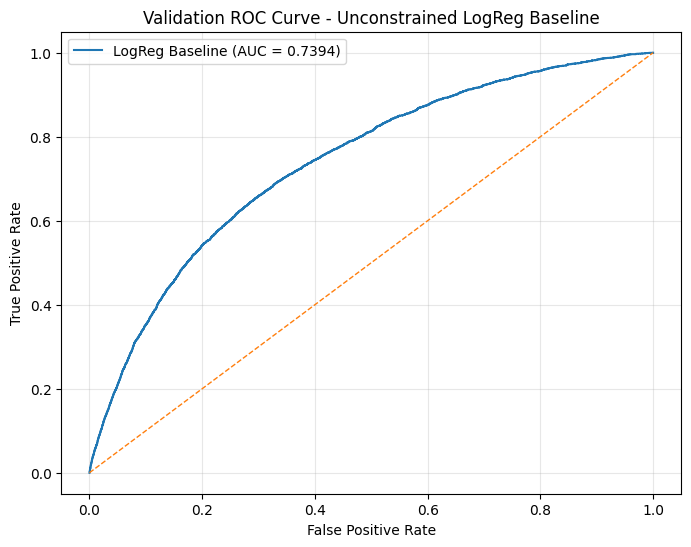

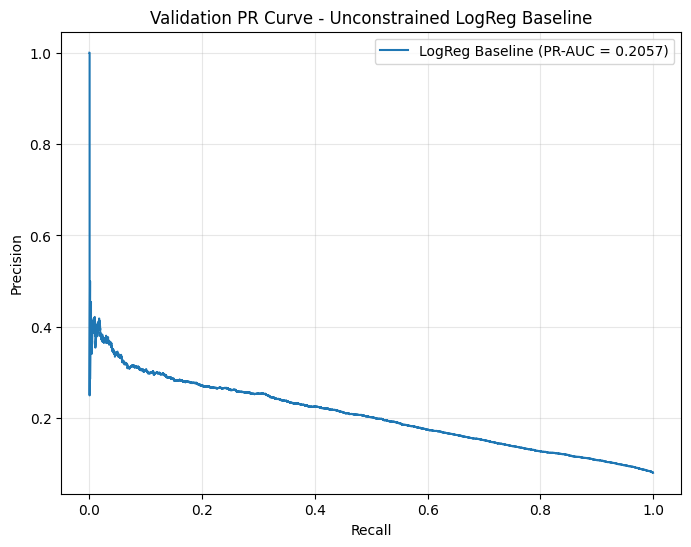

In [13]:
plot_roc_curves(
    curves_dict={"LogReg Baseline": (y_val, baseline_val_prob)},
    title="Validation ROC Curve - Unconstrained LogReg Baseline",
)
plot_pr_curves(
    curves_dict={"LogReg Baseline": (y_val, baseline_val_prob)},
    title="Validation PR Curve - Unconstrained LogReg Baseline",
)

### Hyperparameter Tuning


Grid search over candidate hyperparameter combinations evaluated on the **validate** split.  
**PR-AUC is the primary selection metric** (preferred over ROC-AUC given class imbalance).

Search space:
- `C` — inverse regularisation strength: 5 values
- `penalty` — L1 (`saga` solver) vs L2 (`lbfgs`)
- `class_weight` — balanced vs None

Total: 5 × 2 × 2 = 20 candidates

In [14]:
def train_and_evaluate_candidate(candidate_params, candidate_name, X_train_r, X_val_r):
    """
    Helper func to train one logistic regression candidate on the training split,
    use the validation split for evaluation,
    and return both the fitted model and its validation metrics.
    Works for both unconstrained and constrained (pass the appropriate X matrices).
    """
    fitted_model = LogisticRegression(
        solver=SOLVER_MAP[candidate_params["penalty"]],
        max_iter=300,         # ← sufficient for tuning; full fit later
        tol=1e-3,             # ← looser tolerance speeds up saga significantly
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **candidate_params,
    )
    fitted_model.fit(X_train_r, y_train)

    validation_result = evaluate_binary_model(
        model=fitted_model, X=X_val_r, y=y_val,
        split_name="validation", model_name=candidate_name,
    )
    for param_name, param_value in candidate_params.items():
        validation_result[param_name] = param_value

    return fitted_model, validation_result

In [15]:
from itertools import product

In [16]:
logreg_search_grid = {
    "C":            [0.01, 0.1, 1.0, 10.0, 100.0],
    "penalty":      ["l1", "l2"],
    "class_weight": ["balanced", None],
}

search_param_names  = list(logreg_search_grid.keys())
search_combinations = list(product(*logreg_search_grid.values()))
print(f"Number of candidate combinations: {len(search_combinations)}")

Number of candidate combinations: 20


In [17]:
unc_search_results = []
unc_search_models  = {}

for i, combo in enumerate(search_combinations, start=1):
    candidate_params = dict(zip(search_param_names, combo))
    candidate_name   = f"logreg_unc_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name,
        X_train_r=X_train_unc,
        X_val_r=X_val_unc,
    )
    unc_search_models[candidate_name] = fitted_model
    unc_search_results.append(validation_result)

unc_search_df = pd.DataFrame(unc_search_results).sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

unc_search_df.to_csv(UNC_TUNING_CSV, index=False)
print(f"Saved: {UNC_TUNING_CSV}")
unc_search_df.head(10)

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_unconstrained_tuning_results_validation.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat,C,penalty,class_weight
0,logreg_unc_candidate_18,validation,0.209218,0.738050,0.069281,0.361685,100.00,l1,NaN
1,logreg_unc_candidate_14,validation,0.209215,0.738048,0.069281,0.361709,10.00,l1,NaN
2,logreg_unc_candidate_10,validation,0.209193,0.738030,0.069282,0.361950,1.00,l1,NaN
3,logreg_unc_candidate_6,validation,0.208924,0.737842,0.069293,0.361185,0.10,l1,NaN
4,logreg_unc_candidate_20,validation,0.207647,0.736590,0.069359,0.356889,100.00,l2,NaN
5,logreg_unc_candidate_16,validation,0.207646,0.736589,0.069359,0.356889,10.00,l2,NaN
6,logreg_unc_candidate_12,validation,0.207643,0.736590,0.069359,0.356937,1.00,l2,NaN
7,logreg_unc_candidate_8,validation,0.207618,0.736594,0.069360,0.356997,0.10,l2,NaN
8,logreg_unc_candidate_4,validation,0.207386,0.736603,0.069363,0.357868,0.01,l2,NaN
9,logreg_unc_candidate_19,validation,0.206101,0.740150,0.206033,0.362599,100.00,l2,balanced


In [18]:
best_unc_name    = unc_search_df.loc[0, "model_name"]
best_logreg_unc  = unc_search_models[best_unc_name]

print("Selected tuned unconstrained logistic regression model:")
print(f"  Candidate name:     {best_unc_name}")
print(f"  C:                  {unc_search_df.loc[0, 'C']}")
print(f"  Penalty:            {unc_search_df.loc[0, 'penalty']}")
print(f"  Class weight:       {unc_search_df.loc[0, 'class_weight']}")
print(f"  Validation PR-AUC:  {unc_search_df.loc[0, 'pr_auc']:.6f}")
print(f"  Validation ROC-AUC: {unc_search_df.loc[0, 'roc_auc']:.6f}")
print(f"  Validation KS:      {unc_search_df.loc[0, 'ks_stat']:.6f}")
print(f"  Validation Brier:   {unc_search_df.loc[0, 'brier_score']:.6f}")

unc_search_df.head(1).to_csv(UNC_SELECTED_CSV, index=False)
print(f"\nSaved: {UNC_SELECTED_CSV}")

Selected tuned unconstrained logistic regression model:
  Candidate name:     logreg_unc_candidate_18
  C:                  100.0
  Penalty:            l1
  Class weight:       nan
  Validation PR-AUC:  0.209218
  Validation ROC-AUC: 0.738050
  Validation KS:      0.361685
  Validation Brier:   0.069281

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_unconstrained_selected_model_validation.csv


In [19]:
tuned_unc_val_result = evaluate_binary_model(
    model=best_logreg_unc, X=X_val_unc, y=y_val,
    split_name="validation", model_name="logreg_unconstrained_tuned",
)
tuned_unc_val_prob = best_logreg_unc.predict_proba(X_val_unc)[:, 1]

unc_validation_compare_df = pd.DataFrame([baseline_val_result, tuned_unc_val_result])
unc_validation_compare_df.to_csv(UNC_VALIDATION_CMP_CSV, index=False)
print(f"Saved: {UNC_VALIDATION_CMP_CSV}")
unc_validation_compare_df

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_unconstrained_validation_comparison.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat
0,logreg_unconstrained_baseline,validation,0.205673,0.739436,0.206017,0.359216
1,logreg_unconstrained_tuned,validation,0.209218,0.738050,0.069281,0.361685


### Interpretation

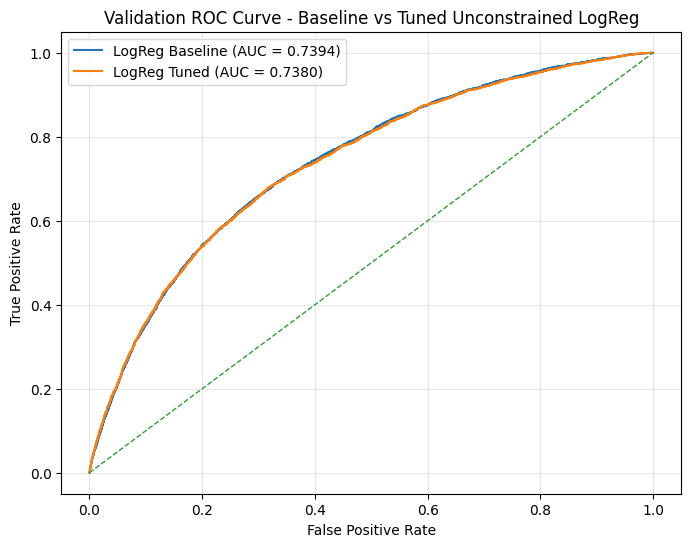

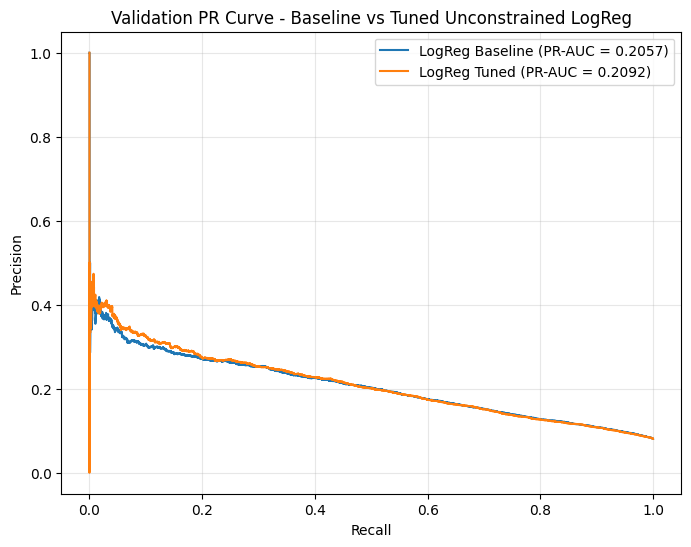

In [20]:
plot_roc_curves(
    curves_dict={
        "LogReg Baseline": (y_val, baseline_val_prob),
        "LogReg Tuned":    (y_val, tuned_unc_val_prob),
    },
    title="Validation ROC Curve - Baseline vs Tuned Unconstrained LogReg",
)
plot_pr_curves(
    curves_dict={
        "LogReg Baseline": (y_val, baseline_val_prob),
        "LogReg Tuned":    (y_val, tuned_unc_val_prob),
    },
    title="Validation PR Curve - Baseline vs Tuned Unconstrained LogReg",
)

In [21]:
display(unc_validation_compare_df)

,model_name,split,pr_auc,roc_auc,brier_score,ks_stat
0,logreg_unconstrained_baseline,validation,0.205673,0.739436,0.206017,0.359216
1,logreg_unconstrained_tuned,validation,0.209218,0.738050,0.069281,0.361685


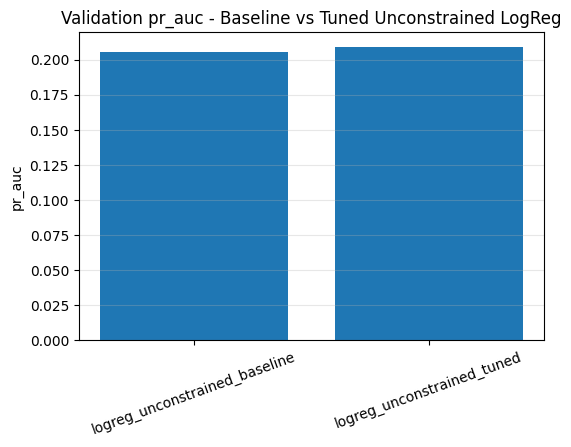

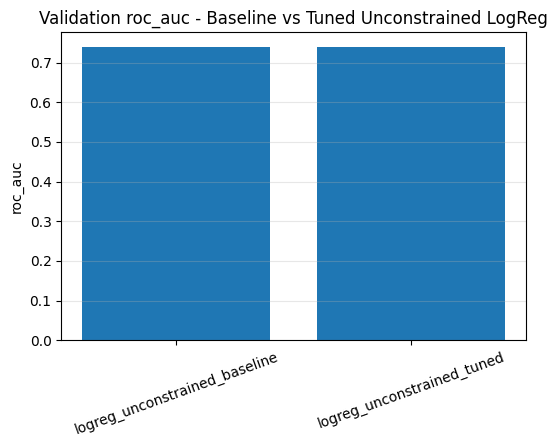

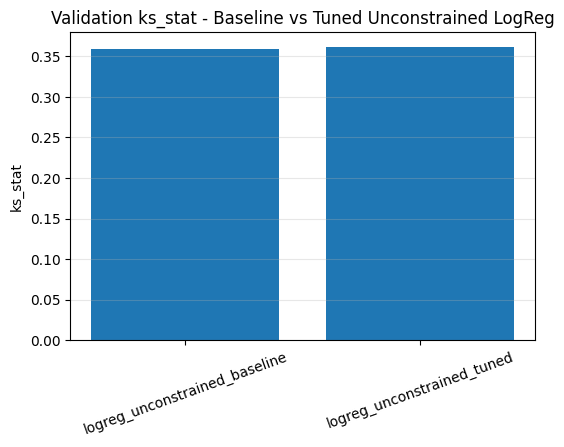

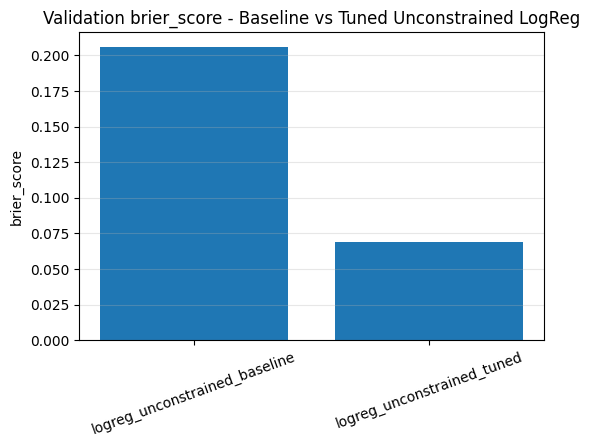

In [22]:
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plt.figure(figsize=(6, 4))
    plt.bar(unc_validation_compare_df["model_name"], unc_validation_compare_df[metric])
    plt.title(f"Validation {metric} - Baseline vs Tuned Unconstrained LogReg")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

## CONSTRAINED LOGISTIC REGRESSION MODEL

Scorecard-style logistic regression with two structural constraints:
1. **Monotonic binning via WoE encoding** — continuous features with a clear economic direction
   are transformed using Weight of Evidence (WoE) binning with monotonicity enforced by
   isotonic regression
2. **Additive structure** — naturally satisfied by logistic regression (linear in log-odds)

Two runs:
- **Fixed** — same hyperparameters as the best unconstrained model (fair comparison)
- **Retuned** — fresh grid search to find the best achievable constrained performance

### Constrained Preprocessing — Monotonic WoE Encoding



WoE encodes each feature as a monotonic transformation of its empirical log-odds relationship with default.  
Bin WoE values are post-processed by isotonic regression to guarantee monotonic ordering.

WoE per bin = log( P(default | bin) / P(non-default | bin) )  

**Fit on training data only** — applied to validate/test without refitting to prevent leakage.  
Missing values receive their own `MISSING` bin WoE computed from NaN rows in training data.

In [23]:
# Monotonic direction per feature (agreed by team)
# +1 = higher feature value -> higher default risk  -> WoE non-decreasing across bins
# -1 = higher feature value -> lower default risk   -> WoE non-increasing across bins
MONOTONIC_DIRECTIONS = {
    "AMT_INCOME_TOTAL":           -1,
    "DAYS_BIRTH":                 -1,
    "DAYS_EMPLOYED":              -1,
    "AMT_REQ_CREDIT_BUREAU_HOUR": +1,
    "AMT_REQ_CREDIT_BUREAU_DAY":  +1,
    "AMT_REQ_CREDIT_BUREAU_WEEK": +1,
    "AMT_REQ_CREDIT_BUREAU_MON":  +1,
    "AMT_REQ_CREDIT_BUREAU_QRT":  +1,
    "AMT_REQ_CREDIT_BUREAU_YEAR": +1,
    "EXT_SOURCE_1":               -1,
    "EXT_SOURCE_2":               -1,
    "EXT_SOURCE_3":               -1,
}

WOE_FEATURES    = list(MONOTONIC_DIRECTIONS.keys())
NON_WOE_NUMERIC = [col for col in numeric_columns if col not in WOE_FEATURES]

print(f"WoE-encoded features ({len(WOE_FEATURES)}):    {WOE_FEATURES}")
print(f"Non-WoE numeric features ({len(NON_WOE_NUMERIC)}): {NON_WOE_NUMERIC}")

WoE-encoded features (12):    ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
Non-WoE numeric features (11): ['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING']


In [24]:
class MonotonicWoEEncoder:
    """
    Encodes continuous features using Weight of Evidence (WoE) binning
    with monotonicity enforced via isotonic regression.
    Fit on training data only; apply saved mapping to validate/test.
    Missing values receive their own WoE bin.
    """

    def __init__(self, n_bins=10):
        self.n_bins       = n_bins
        self.bin_edges_   = {}
        self.woe_maps_    = {}
        self.missing_woe_ = {}

    def fit(self, X, y, monotonic_directions):
        self.monotonic_directions_ = monotonic_directions
        total_events     = float(y.sum())
        total_non_events = float((1 - y).sum())

        for feature, direction in monotonic_directions.items():
            col     = X[feature].copy().reset_index(drop=True)
            y_r     = y.reset_index(drop=True)
            is_miss = col.isna()

            # WoE for missing bin
            miss_e = float(y_r[is_miss].sum())
            miss_n = float((1 - y_r[is_miss]).sum())
            self.missing_woe_[feature] = float(
                np.log(max(miss_e / total_events, 1e-6) / max(miss_n / total_non_events, 1e-6))
            )

            # Quantile bin edges on non-missing values
            non_miss = col[~is_miss]
            edges    = np.unique(np.percentile(non_miss, np.linspace(0, 100, self.n_bins + 1)))
            edges[0], edges[-1] = -np.inf, np.inf
            self.bin_edges_[feature] = edges

            bin_idx = pd.cut(non_miss, bins=edges, labels=False, include_lowest=True)
            n_bins  = len(edges) - 1
            raw_woe = []

            for b in range(n_bins):
                mask = bin_idx == b
                b_e  = float(y_r[~is_miss][mask].sum())
                b_n  = float((1 - y_r[~is_miss][mask]).sum())
                raw_woe.append(float(
                    np.log(max(b_e / total_events, 1e-6) / max(b_n / total_non_events, 1e-6))
                ))

            # Enforce monotonicity
            iso      = IsotonicRegression(increasing=(direction == 1))
            mono_woe = iso.fit_transform(list(range(n_bins)), raw_woe)
            self.woe_maps_[feature] = dict(zip(range(n_bins), mono_woe))

        return self

    def transform(self, X):
        X_out = X.copy()
        for feature, woe_map in self.woe_maps_.items():
            col     = X[feature].copy()
            is_miss = col.isna()
            edges   = self.bin_edges_[feature]
            bin_idx = pd.cut(col, bins=edges, labels=False, include_lowest=True)
            out     = bin_idx.map(woe_map)
            out[is_miss] = self.missing_woe_[feature]
            X_out[feature] = out.fillna(0.0)
        return X_out

    def fit_transform(self, X, y, monotonic_directions):
        return self.fit(X, y, monotonic_directions).transform(X)

In [25]:
woe_encoder = MonotonicWoEEncoder(n_bins=10)
X_train_woe = woe_encoder.fit_transform(X_train, y_train, MONOTONIC_DIRECTIONS)
X_val_woe   = woe_encoder.transform(X_val)
X_test_woe  = woe_encoder.transform(X_test)

# Verify monotonicity
print("Monotonicity verification:")
for feature, direction in MONOTONIC_DIRECTIONS.items():
    woe_vals = list(woe_encoder.woe_maps_[feature].values())
    diffs    = np.diff(woe_vals)
    is_mono  = bool(np.all(diffs >= -1e-9)) if direction == 1 else bool(np.all(diffs <= 1e-9))
    print(f"  [{'OK' if is_mono else 'FAIL'}] {feature} ({'+'  if direction == 1 else '-'})")

Monotonicity verification:
  [OK] AMT_INCOME_TOTAL (-)
  [OK] DAYS_BIRTH (-)
  [OK] DAYS_EMPLOYED (-)
  [OK] AMT_REQ_CREDIT_BUREAU_HOUR (+)
  [OK] AMT_REQ_CREDIT_BUREAU_DAY (+)
  [OK] AMT_REQ_CREDIT_BUREAU_WEEK (+)
  [OK] AMT_REQ_CREDIT_BUREAU_MON (+)
  [OK] AMT_REQ_CREDIT_BUREAU_QRT (+)
  [OK] AMT_REQ_CREDIT_BUREAU_YEAR (+)
  [OK] EXT_SOURCE_1 (-)
  [OK] EXT_SOURCE_2 (-)
  [OK] EXT_SOURCE_3 (-)


In [26]:
# Impute + scale non-WoE numeric features, then OHE categoricals
con_imputer = SimpleImputer(strategy="median")
con_scaler  = StandardScaler()

X_train_con = X_train_woe.copy()
X_val_con   = X_val_woe.copy()
X_test_con  = X_test_woe.copy()

X_train_con[NON_WOE_NUMERIC] = con_imputer.fit_transform(X_train_woe[NON_WOE_NUMERIC])
X_val_con[NON_WOE_NUMERIC]   = con_imputer.transform(X_val_woe[NON_WOE_NUMERIC])
X_test_con[NON_WOE_NUMERIC]  = con_imputer.transform(X_test_woe[NON_WOE_NUMERIC])

X_train_con[numeric_columns] = con_scaler.fit_transform(X_train_con[numeric_columns])
X_val_con[numeric_columns]   = con_scaler.transform(X_val_con[numeric_columns])
X_test_con[numeric_columns]  = con_scaler.transform(X_test_con[numeric_columns])

X_train_con = pd.get_dummies(X_train_con, columns=categorical_columns, drop_first=False, dtype=int)
X_val_con   = pd.get_dummies(X_val_con,   columns=categorical_columns, drop_first=False, dtype=int)
X_test_con  = pd.get_dummies(X_test_con,  columns=categorical_columns, drop_first=False, dtype=int)

X_val_con   = X_val_con.reindex(columns=X_train_con.columns, fill_value=0)
X_test_con  = X_test_con.reindex(columns=X_train_con.columns, fill_value=0)

print("Train/validate columns match:", list(X_train_con.columns) == list(X_val_con.columns))
print(f"\nFinal constrained shapes:")
print(f"  X_train_con: {X_train_con.shape}")
print(f"  X_val_con:   {X_val_con.shape}")
print(f"  X_test_con:  {X_test_con.shape}")

Train/validate columns match: True

Final constrained shapes:
  X_train_con: (215137, 129)
  X_val_con:   (46101, 129)
  X_test_con:  (46101, 129)


### Constrained Model — Fixed Hyperparameters

Uses the **same hyperparameters** as the best unconstrained model.  
This isolates the cost of the constraint from the effect of different hyperparameters.

In [28]:
# Load best unconstrained hyperparameters from saved CSV
unc_best_row   = pd.read_csv(UNC_SELECTED_CSV).iloc[0]
FIXED_C        = float(unc_best_row["C"])
FIXED_PENALTY  = str(unc_best_row["penalty"])
raw_cw         = unc_best_row["class_weight"]
FIXED_CLASS_WT = None if pd.isna(raw_cw) else str(raw_cw)

print(f"C={FIXED_C}, penalty={FIXED_PENALTY}, class_weight={FIXED_CLASS_WT!r}")

logreg_con_fixed = LogisticRegression(
    penalty=FIXED_PENALTY, C=FIXED_C,
    solver=SOLVER_MAP[FIXED_PENALTY],
    class_weight=FIXED_CLASS_WT,
    max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1,
)
logreg_con_fixed.fit(X_train_con, y_train)

fixed_val_prob   = logreg_con_fixed.predict_proba(X_val_con)[:, 1]
fixed_val_result = evaluate_binary_model(
    model=logreg_con_fixed, X=X_val_con, y=y_val,
    split_name="validation", model_name="logreg_constrained_fixed",
)
fixed_val_result.update({"C": FIXED_C, "penalty": FIXED_PENALTY,
"class_weight": str(FIXED_CLASS_WT)})
pd.DataFrame([fixed_val_result]).to_csv(CON_FIXED_CSV, index=False)
print(f"PR-AUC: {fixed_val_result['pr_auc']:.6f} | ROC-AUC: {fixed_val_result['roc_auc']:.6f}")
print(f"Saved: {CON_FIXED_CSV}")

C=100.0, penalty=l1, class_weight=None
PR-AUC: 0.206859 | ROC-AUC: 0.737975
Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_constrained_fixed_selected_model_validation.csv


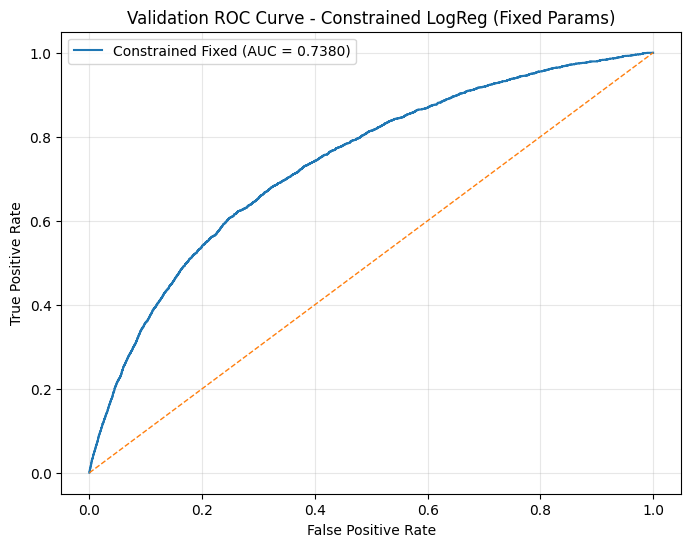

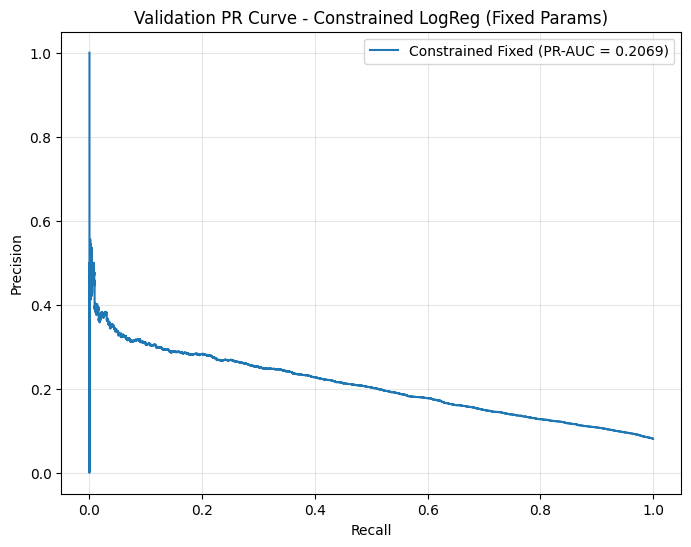

In [29]:
plot_roc_curves(
    curves_dict={"Constrained Fixed": (y_val, fixed_val_prob)},
    title="Validation ROC Curve - Constrained LogReg (Fixed Params)",
)
plot_pr_curves(
    curves_dict={"Constrained Fixed": (y_val, fixed_val_prob)},
    title="Validation PR Curve - Constrained LogReg (Fixed Params)",
)

### Constrained Model — Retuned Hyperparameters

Fresh grid search on the constrained model. Same search space as unconstrained.

In [30]:
con_search_results = []
con_search_models  = {}

for i, combo in enumerate(search_combinations, start=1):
    candidate_params = dict(zip(search_param_names, combo))
    candidate_name   = f"logreg_con_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name,
        X_train_r=X_train_con,
        X_val_r=X_val_con,
    )
    con_search_models[candidate_name] = fitted_model
    con_search_results.append(validation_result)

con_search_df = pd.DataFrame(con_search_results).sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

con_search_df.to_csv(CON_RETUNED_TUNING_CSV, index=False)
print(f"Saved: {CON_RETUNED_TUNING_CSV}")
con_search_df.head(10)

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_constrained_retuned_tuning_results_validation.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat,C,penalty,class_weight
0,logreg_con_candidate_6,validation,0.207320,0.738514,0.069318,0.361611,0.10,l1,NaN
1,logreg_con_candidate_10,validation,0.206956,0.738218,0.069337,0.359898,1.00,l1,NaN
2,logreg_con_candidate_14,validation,0.206872,0.738054,0.069343,0.359369,10.00,l1,NaN
3,logreg_con_candidate_18,validation,0.206733,0.738033,0.069343,0.359299,100.00,l1,NaN
4,logreg_con_candidate_16,validation,0.204221,0.735137,0.069473,0.353183,10.00,l2,NaN
5,logreg_con_candidate_20,validation,0.204220,0.735137,0.069473,0.353160,100.00,l2,NaN
6,logreg_con_candidate_12,validation,0.204218,0.735137,0.069473,0.353160,1.00,l2,NaN
7,logreg_con_candidate_8,validation,0.204193,0.735140,0.069473,0.353835,0.10,l2,NaN
8,logreg_con_candidate_4,validation,0.204064,0.735155,0.069476,0.353867,0.01,l2,NaN
9,logreg_con_candidate_2,validation,0.203906,0.735488,0.069460,0.356278,0.01,l1,NaN


In [31]:
best_con_name    = con_search_df.loc[0, "model_name"]
best_logreg_con  = con_search_models[best_con_name]

print("Selected retuned constrained logistic regression model:")
print(f"  Candidate name:     {best_con_name}")
print(f"  C:                  {con_search_df.loc[0, 'C']}")
print(f"  Penalty:            {con_search_df.loc[0, 'penalty']}")
print(f"  Class weight:       {con_search_df.loc[0, 'class_weight']}")
print(f"  Validation PR-AUC:  {con_search_df.loc[0, 'pr_auc']:.6f}")
print(f"  Validation ROC-AUC: {con_search_df.loc[0, 'roc_auc']:.6f}")
print(f"  Validation KS:      {con_search_df.loc[0, 'ks_stat']:.6f}")
print(f"  Validation Brier:   {con_search_df.loc[0, 'brier_score']:.6f}")

con_search_df.head(1).to_csv(CON_RETUNED_SELECTED_CSV, index=False)
print(f"\nSaved: {CON_RETUNED_SELECTED_CSV}")

Selected retuned constrained logistic regression model:
  Candidate name:     logreg_con_candidate_6
  C:                  0.1
  Penalty:            l1
  Class weight:       nan
  Validation PR-AUC:  0.207320
  Validation ROC-AUC: 0.738514
  Validation KS:      0.361611
  Validation Brier:   0.069318

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_constrained_retuned_selected_model_validation.csv


In [32]:
retuned_val_result = evaluate_binary_model(
    model=best_logreg_con, X=X_val_con, y=y_val,
    split_name="validation", model_name="logreg_constrained_retuned",
)
retuned_val_prob = best_logreg_con.predict_proba(X_val_con)[:, 1]

con_validation_compare_df = pd.DataFrame([fixed_val_result, retuned_val_result])
con_validation_compare_df.to_csv(CON_VALIDATION_CMP_CSV, index=False)
print(f"Saved: {CON_VALIDATION_CMP_CSV}")

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_constrained_validation_comparison.csv


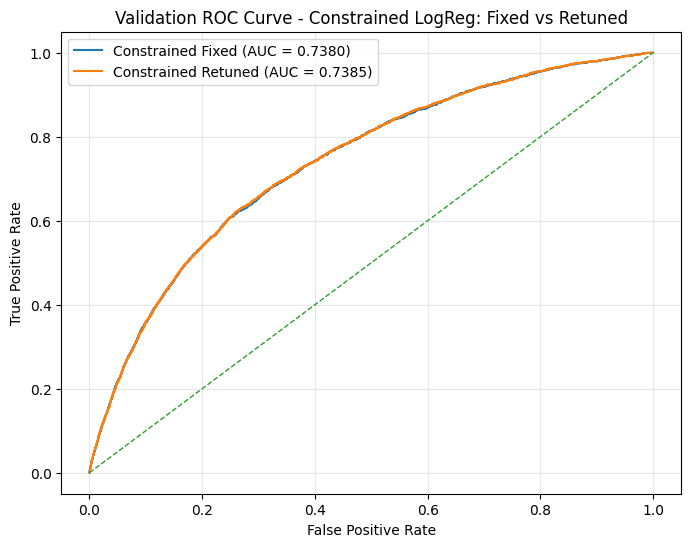

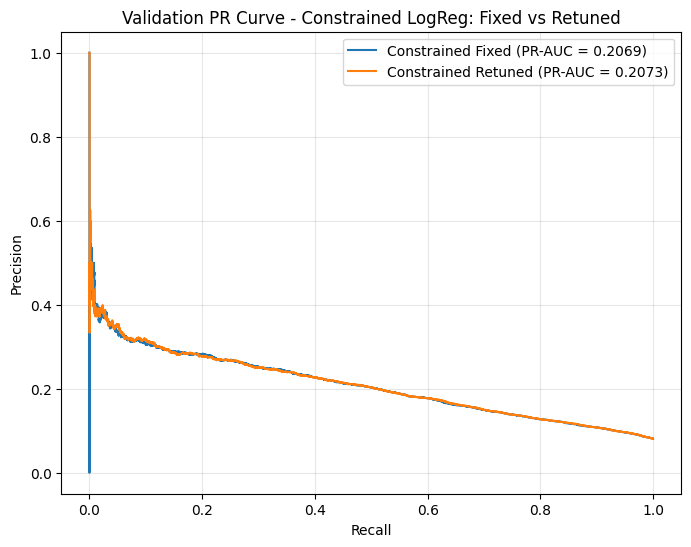

In [33]:
plot_roc_curves(
    curves_dict={
        "Constrained Fixed":   (y_val, fixed_val_prob),
        "Constrained Retuned": (y_val, retuned_val_prob),
    },
    title="Validation ROC Curve - Constrained LogReg: Fixed vs Retuned",
)
plot_pr_curves(
    curves_dict={
        "Constrained Fixed":   (y_val, fixed_val_prob),
        "Constrained Retuned": (y_val, retuned_val_prob),
    },
    title="Validation PR Curve - Constrained LogReg: Fixed vs Retuned",
)

In [34]:
display(con_validation_compare_df)

,model_name,split,pr_auc,roc_auc,brier_score,ks_stat,C,penalty,class_weight
0,logreg_constrained_fixed,validation,0.206859,0.737975,0.069339,0.358974,100.0,l1,None
1,logreg_constrained_retuned,validation,0.207320,0.738514,0.069318,0.361611,NaN,NaN,NaN


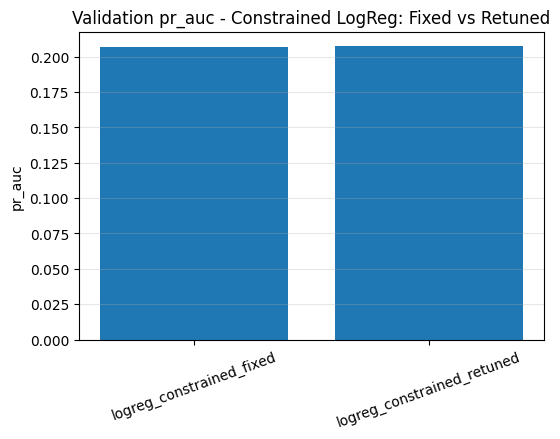

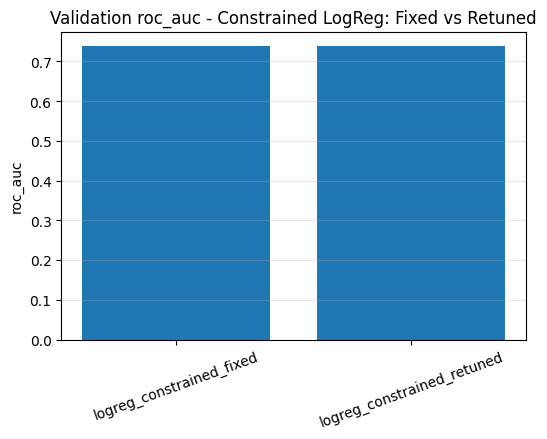

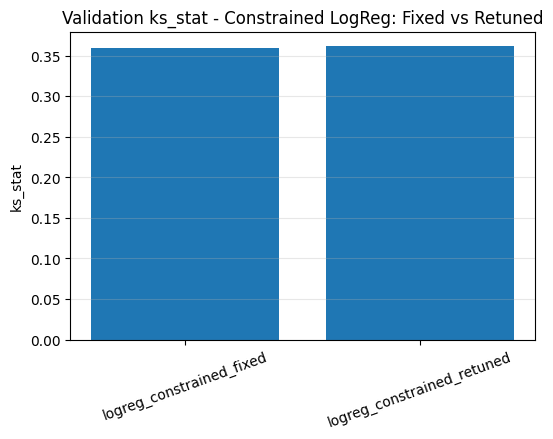

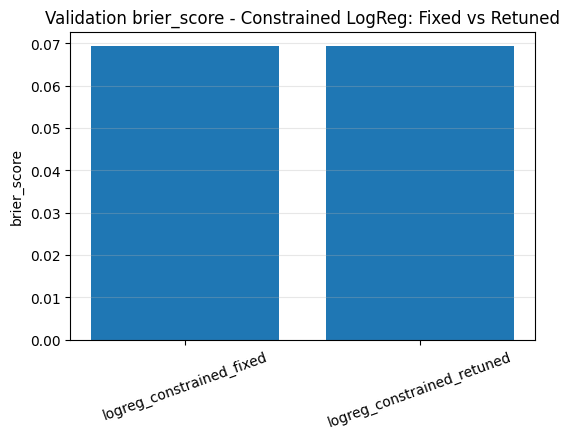

In [35]:
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plt.figure(figsize=(6, 4))
    plt.bar(con_validation_compare_df["model_name"], con_validation_compare_df[metric])
    plt.title(f"Validation {metric} - Constrained LogReg: Fixed vs Retuned")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

## FINAL COMPARISON

Side-by-side comparison of all three model variants on the validation set.

| Model | Description |
|---|---|
| `logreg_unconstrained_tuned` | Best unconstrained model |
| `logreg_constrained_fixed` | Constrained — same params as unconstrained |
| `logreg_constrained_retuned` | Constrained — independently retuned |

In [36]:
final_comparison_df = pd.DataFrame([
    evaluate_binary_model(best_logreg_unc, X_val_unc, y_val, "validation", "logreg_unconstrained_tuned"),
    evaluate_binary_model(logreg_con_fixed, X_val_con, y_val, "validation", "logreg_constrained_fixed"),
    evaluate_binary_model(best_logreg_con,  X_val_con, y_val, "validation", "logreg_constrained_retuned"),
])

final_comparison_df.to_csv(FINAL_COMPARISON_CSV, index=False)
print(f"Saved: {FINAL_COMPARISON_CSV}")
display(final_comparison_df)

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_final_comparison.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat
0,logreg_unconstrained_tuned,validation,0.209218,0.738050,0.069281,0.361685
1,logreg_constrained_fixed,validation,0.206859,0.737975,0.069339,0.358974
2,logreg_constrained_retuned,validation,0.207320,0.738514,0.069318,0.361611


In [37]:
unc_row = final_comparison_df[final_comparison_df["model_name"] == "logreg_unconstrained_tuned"].iloc[0]

delta_rows = []
for _, row in final_comparison_df[final_comparison_df["model_name"] != "logreg_unconstrained_tuned"].iterrows():
    delta_rows.append({
        "model_name":        row["model_name"],
        "delta_pr_auc":      round(row["pr_auc"]     - unc_row["pr_auc"],      6),
        "delta_roc_auc":     round(row["roc_auc"]    - unc_row["roc_auc"],     6),
        "delta_ks_stat":     round(row["ks_stat"]    - unc_row["ks_stat"],     6),
        "delta_brier_score": round(row["brier_score"] - unc_row["brier_score"], 6),
    })

print("Performance delta vs unconstrained (negative = loss from constraint):")
display(pd.DataFrame(delta_rows))

Performance delta vs unconstrained (negative = loss from constraint):


,model_name,delta_pr_auc,delta_roc_auc,delta_ks_stat,delta_brier_score
0,logreg_constrained_fixed,-0.002359,-0.000075,-0.002712,0.000058
1,logreg_constrained_retuned,-0.001898,0.000464,-0.000075,0.000038


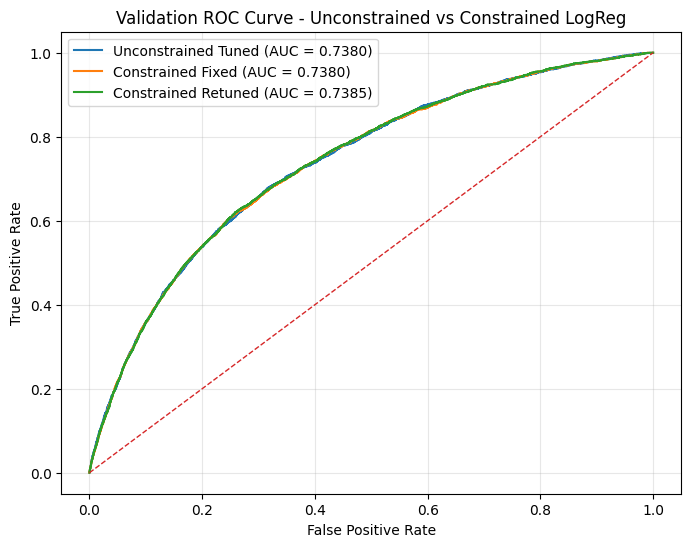

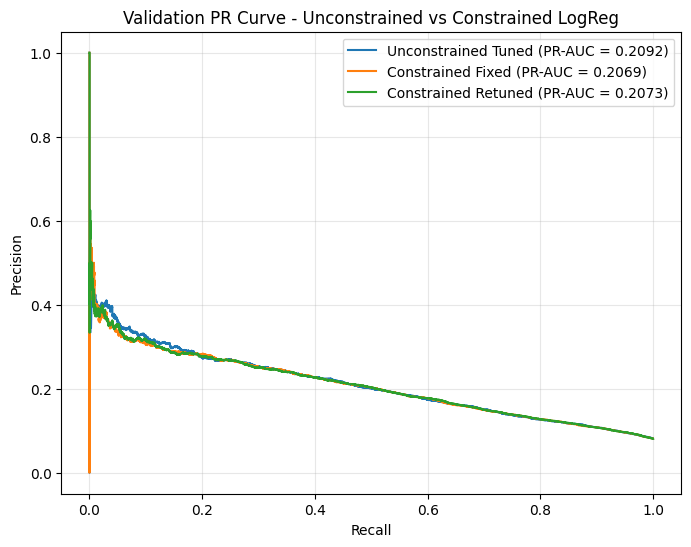

In [38]:
plot_roc_curves(
    curves_dict={
        "Unconstrained Tuned":   (y_val, tuned_unc_val_prob),
        "Constrained Fixed":     (y_val, fixed_val_prob),
        "Constrained Retuned":   (y_val, retuned_val_prob),
    },
    title="Validation ROC Curve - Unconstrained vs Constrained LogReg",
)
plot_pr_curves(
    curves_dict={
        "Unconstrained Tuned":   (y_val, tuned_unc_val_prob),
        "Constrained Fixed":     (y_val, fixed_val_prob),
        "Constrained Retuned":   (y_val, retuned_val_prob),
    },
    title="Validation PR Curve - Unconstrained vs Constrained LogReg",
)

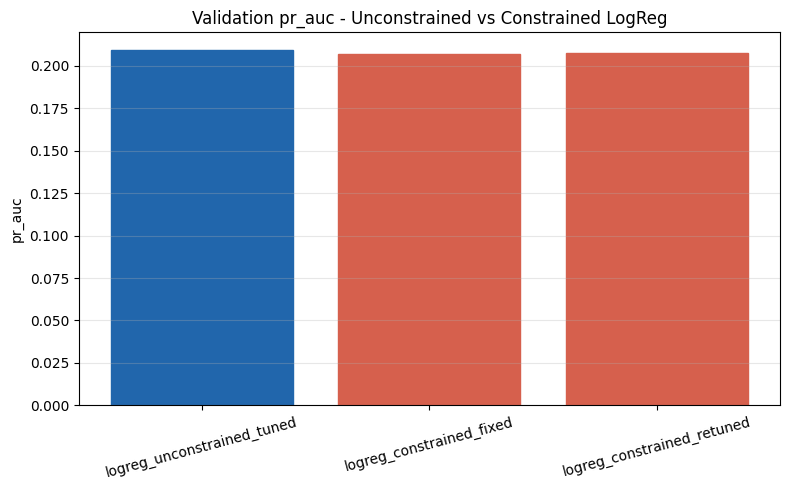

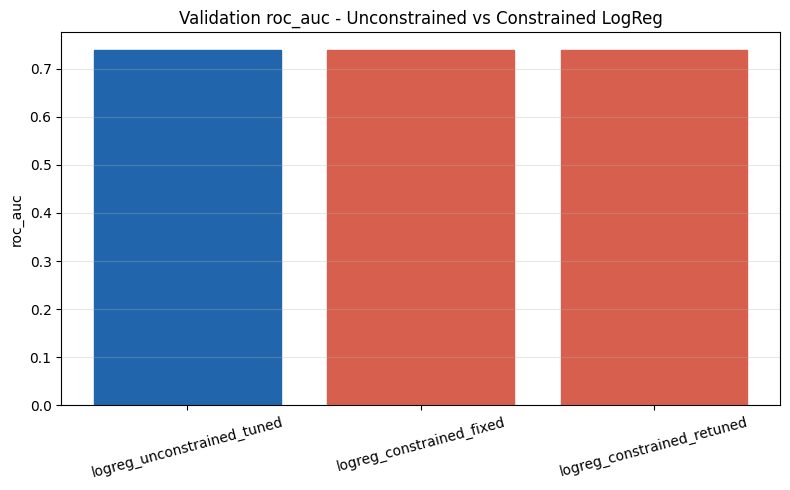

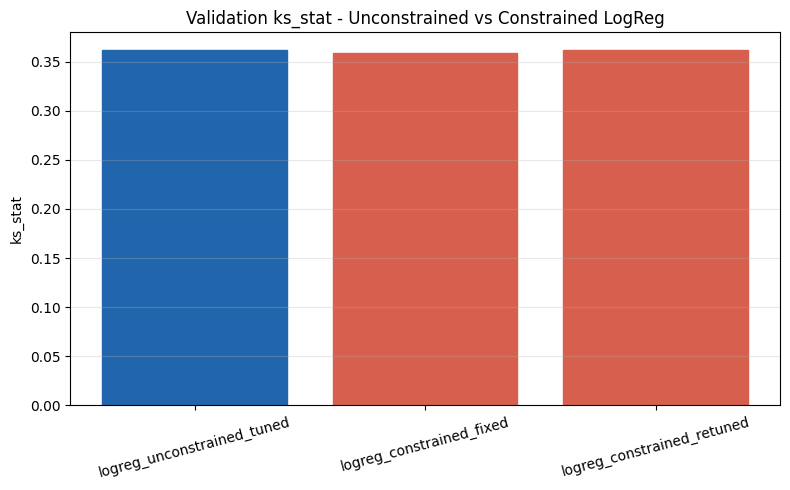

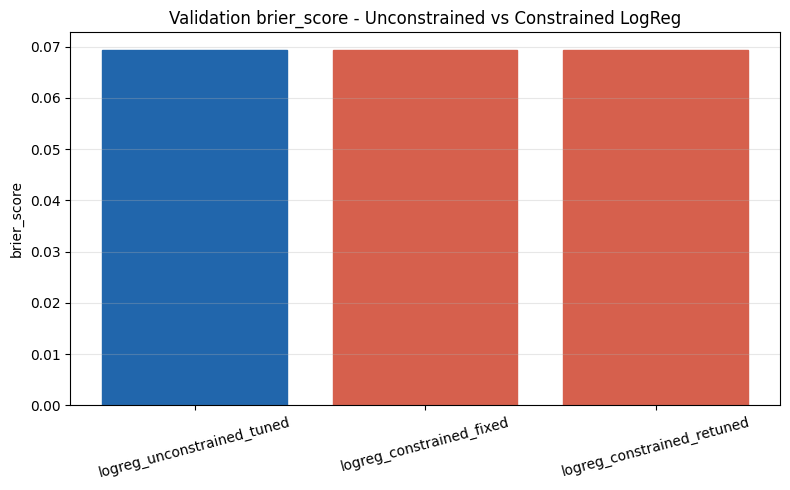

In [39]:
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(final_comparison_df["model_name"], final_comparison_df[metric])
    for bar, name in zip(bars, final_comparison_df["model_name"]):
        bar.set_color("#2166ac" if name == "logreg_unconstrained_tuned" else "#d6604d")
    plt.title(f"Validation {metric} - Unconstrained vs Constrained LogReg")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(LOGREG_OUTPUT_DIR / f"logreg_comparison_{metric}.png", dpi=150)
    plt.show()

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_final_test_results.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat
0,logreg_unconstrained_tuned,test,0.209982,0.736075,0.069308,0.358021
1,logreg_constrained_fixed,test,0.211184,0.737367,0.069223,0.363606
2,logreg_constrained_retuned,test,0.211110,0.737090,0.069239,0.362334



Validation vs Test (negative delta = drop on test):


,model_name,val_pr_auc,test_pr_auc,delta_pr_auc,delta_roc_auc,delta_ks_stat,delta_brier_score
0,logreg_unconstrained_tuned,0.209218,0.209982,0.000764,-0.001975,-0.003664,0.000027
1,logreg_constrained_fixed,0.206859,0.211184,0.004325,-0.000608,0.004632,-0.000116
2,logreg_constrained_retuned,0.207320,0.211110,0.003790,-0.001424,0.000724,-0.000080


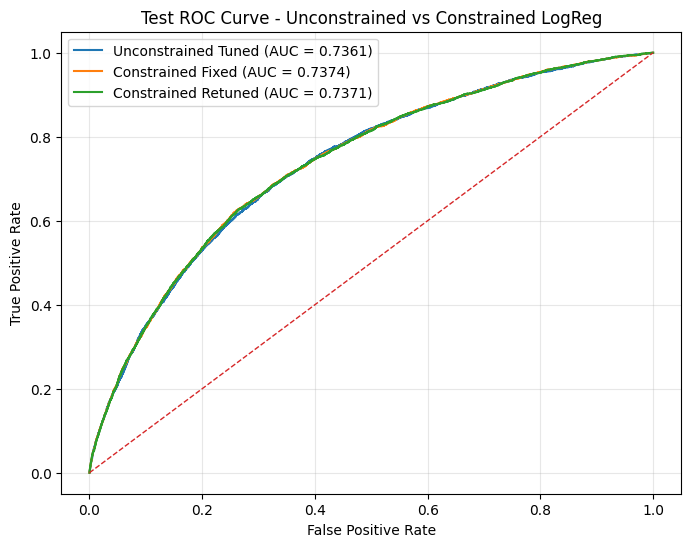

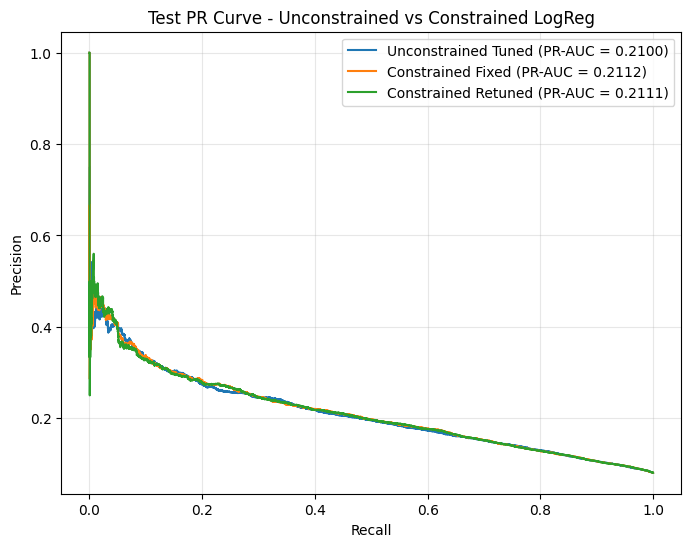

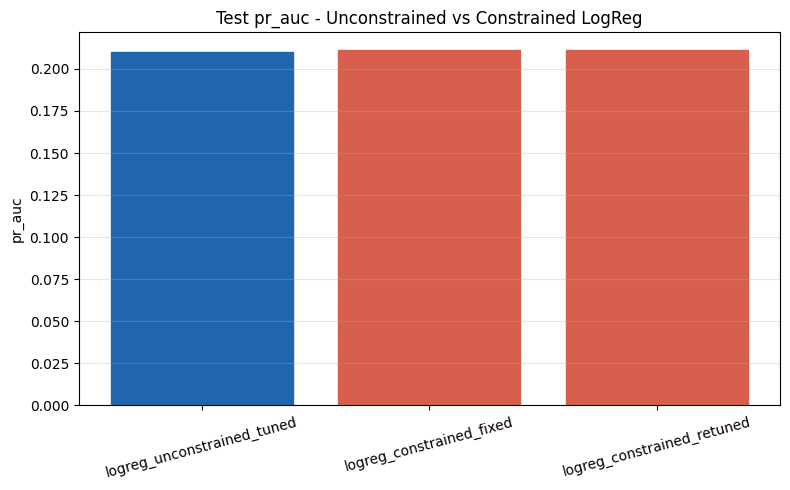

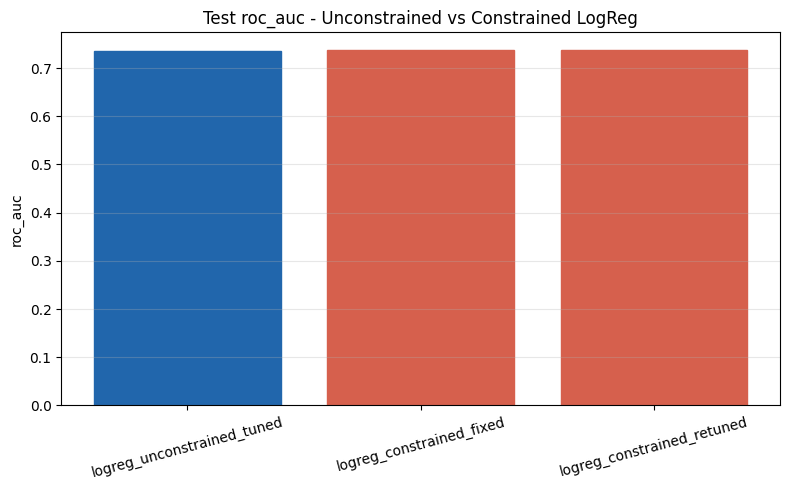

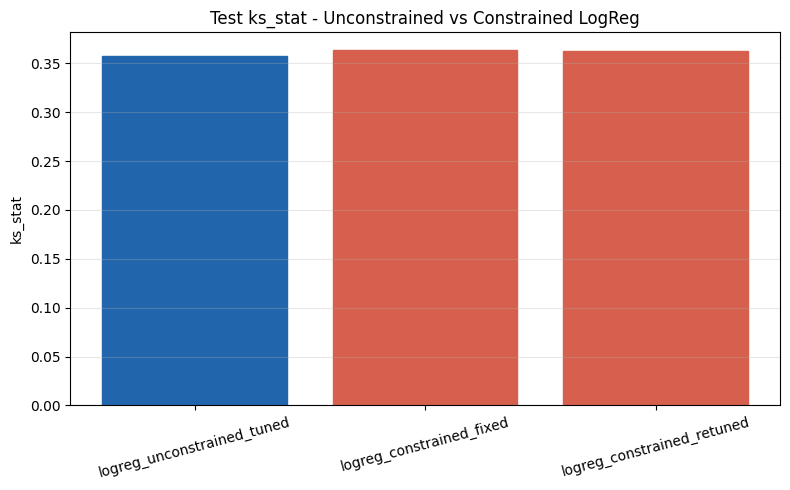

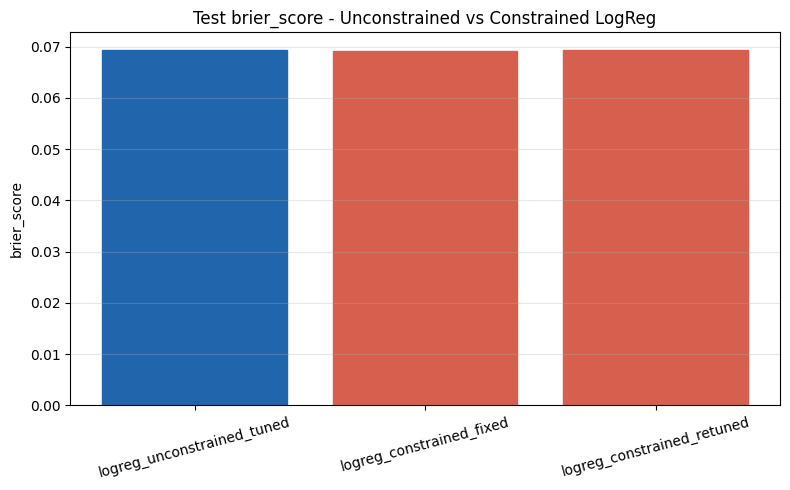

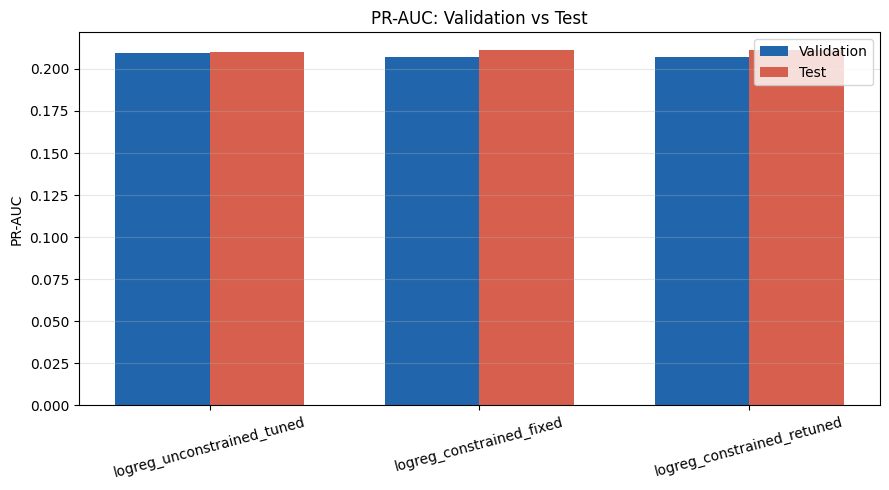

In [40]:
## FINAL TEST SET EVALUATION

TEST_RESULTS_CSV = LOGREG_OUTPUT_DIR / "logreg_final_test_results.csv"
TEST_DELTA_CSV   = LOGREG_OUTPUT_DIR / "logreg_final_test_vs_validation.csv"

# Score all three selected models on the test set
test_results_df = pd.DataFrame([
    evaluate_binary_model(best_logreg_unc, X_test_unc, y_test, "test", "logreg_unconstrained_tuned"),
    evaluate_binary_model(logreg_con_fixed, X_test_con, y_test, "test", "logreg_constrained_fixed"),
    evaluate_binary_model(best_logreg_con,  X_test_con, y_test, "test", "logreg_constrained_retuned"),
])

test_results_df.to_csv(TEST_RESULTS_CSV, index=False)
print(f"Saved: {TEST_RESULTS_CSV}")
display(test_results_df)

# Cache predicted probabilities for plotting
test_unc_prob     = best_logreg_unc.predict_proba(X_test_unc)[:, 1]
test_fixed_prob   = logreg_con_fixed.predict_proba(X_test_con)[:, 1]
test_retuned_prob = best_logreg_con.predict_proba(X_test_con)[:, 1]

### Validation vs Test — check for overfitting / generalization gap
val_vs_test_rows = []
for model_name in test_results_df["model_name"]:
    val_row  = final_comparison_df[final_comparison_df["model_name"] == model_name].iloc[0]
    test_row = test_results_df[test_results_df["model_name"] == model_name].iloc[0]
    val_vs_test_rows.append({
        "model_name":        model_name,
        "val_pr_auc":        round(val_row["pr_auc"], 6),
        "test_pr_auc":       round(test_row["pr_auc"], 6),
        "delta_pr_auc":      round(test_row["pr_auc"]      - val_row["pr_auc"], 6),
        "delta_roc_auc":     round(test_row["roc_auc"]     - val_row["roc_auc"], 6),
        "delta_ks_stat":     round(test_row["ks_stat"]     - val_row["ks_stat"], 6),
        "delta_brier_score": round(test_row["brier_score"] - val_row["brier_score"], 6),
    })

val_vs_test_df = pd.DataFrame(val_vs_test_rows)
val_vs_test_df.to_csv(TEST_DELTA_CSV, index=False)
print(f"\nValidation vs Test (negative delta = drop on test):")
display(val_vs_test_df)

### Plots — ROC and PR curves on test set
plot_roc_curves(
    curves_dict={
        "Unconstrained Tuned": (y_test, test_unc_prob),
        "Constrained Fixed":   (y_test, test_fixed_prob),
        "Constrained Retuned": (y_test, test_retuned_prob),
    },
    title="Test ROC Curve - Unconstrained vs Constrained LogReg",
)
plot_pr_curves(
    curves_dict={
        "Unconstrained Tuned": (y_test, test_unc_prob),
        "Constrained Fixed":   (y_test, test_fixed_prob),
        "Constrained Retuned": (y_test, test_retuned_prob),
    },
    title="Test PR Curve - Unconstrained vs Constrained LogReg",
)

### Bar charts — per-metric comparison on test set
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(test_results_df["model_name"], test_results_df[metric])
    for bar, name in zip(bars, test_results_df["model_name"]):
        bar.set_color("#2166ac" if name == "logreg_unconstrained_tuned" else "#d6604d")
    plt.title(f"Test {metric} - Unconstrained vs Constrained LogReg")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(LOGREG_OUTPUT_DIR / f"logreg_test_{metric}.png", dpi=150)
    plt.show()

### Side-by-side validation vs test bar chart (PR-AUC, the primary metric)
combined = final_comparison_df[["model_name", "pr_auc"]].rename(columns={"pr_auc": "validation"}).merge(
    test_results_df[["model_name", "pr_auc"]].rename(columns={"pr_auc": "test"}),
    on="model_name",
)

x       = np.arange(len(combined))
width   = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, combined["validation"], width, label="Validation", color="#2166ac")
plt.bar(x + width/2, combined["test"],       width, label="Test",       color="#d6604d")
plt.xticks(x, combined["model_name"], rotation=15)
plt.ylabel("PR-AUC")
plt.title("PR-AUC: Validation vs Test")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(LOGREG_OUTPUT_DIR / "logreg_val_vs_test_pr_auc.png", dpi=150)
plt.show()